In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv("../data/results.csv")

In [3]:
results = results[
    [
        "grid",
        "points",
        "positionOrder"
    ]
]

In [4]:
results["winner"] = np.where(
    results["positionOrder"] == 1,
    1,
    0
)

In [5]:
X = results[
    [
        "grid",
        "points"
    ]
]

y = results["winner"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

LogisticRegression()

In [8]:
predictions = model.predict(X_test)

In [9]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.9538490284005979


In [10]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[5045   79]
 [ 168   60]]


In [11]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      5124
           1       0.43      0.26      0.33       228

    accuracy                           0.95      5352
   macro avg       0.70      0.62      0.65      5352
weighted avg       0.94      0.95      0.95      5352



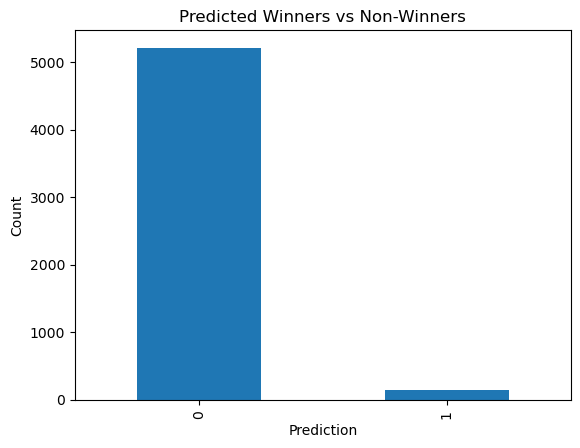

In [12]:
pd.Series(predictions).value_counts().plot(
    kind="bar"
)

plt.title(
    "Predicted Winners vs Non-Winners"
)

plt.xlabel("Prediction")
plt.ylabel("Count")

plt.show()

# Conclusion

The Logistic Regression model was evaluated using multiple metrics.

Accuracy alone is not sufficient because Formula 1 winner prediction is an imbalanced classification problem.

The confusion matrix and classification report provide deeper insights into model performance.